In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 12)

## Load the data

In [2]:
freq = "15min"
resampled_data_path = Path(f"../data/resampled-{freq}/total_power.csv")

<Axes: xlabel='_time'>

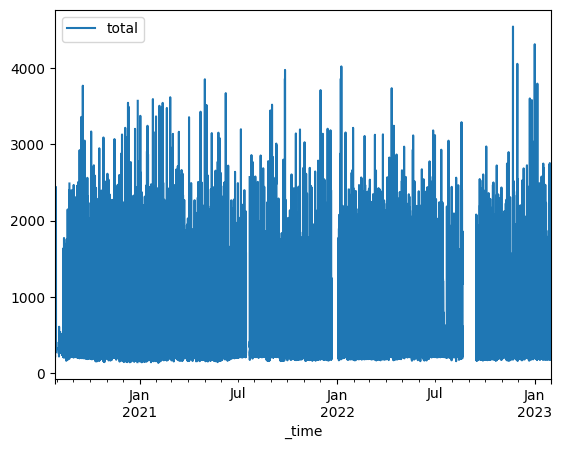

In [3]:
resampled_data = pd.read_csv(resampled_data_path, index_col=0, parse_dates=True)
resampled_data.plot()

## Find a mapping

In [4]:
target_year = 2022

### Find the days that have gaps

,has_gap,replacement,used
2020-07-28 00:00:00+00:00,False,2020-07-28 00:00:00+00:00,False
2020-07-29 00:00:00+00:00,True,2020-07-29 00:00:00+00:00,False
2020-07-30 00:00:00+00:00,True,2020-07-30 00:00:00+00:00,False
2020-07-31 00:00:00+00:00,True,2020-07-31 00:00:00+00:00,False
2020-08-01 00:00:00+00:00,True,2020-08-01 00:00:00+00:00,False
...,...,...,...
2023-01-26 00:00:00+00:00,False,2023-01-26 00:00:00+00:00,False
2023-01-27 00:00:00+00:00,False,2023-01-27 00:00:00+00:00,False
2023-01-28 00:00:00+00:00,False,2023-01-28 00:00:00+00:00,False
2023-01-29 00:00:00+00:00,False,2023-01-29 00:00:00+00:00,False


<Axes: >

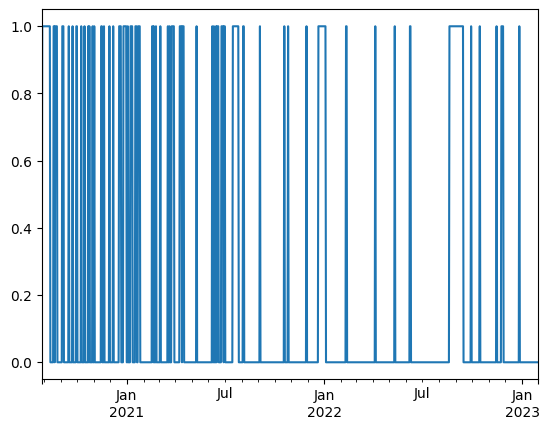

In [5]:
substitution_mapping = resampled_data.groupby(
    resampled_data.index.date).apply(lambda g: g.isna().any())
substitution_mapping.set_index(pd.to_datetime(substitution_mapping.index, utc=True), inplace=True)
substitution_mapping.columns = ["has_gap"]
substitution_mapping["replacement"] = substitution_mapping.index
substitution_mapping["used"] = False
display(substitution_mapping)
substitution_mapping["has_gap"].astype(int).plot()

### The closest substitute for each incomplete day
The closest substitute is
- the same weekday
- from another year
- that has no gaps
- and is as close as possible in terms of time in year

Caveat: The current implementation is not cyclical. Meaning that when replacing Jan 1st, Jan 10th is closer than December 31st (for better readablity, this example does not take the weekday constraint into account).

In [6]:
def closest_substitute(df, day):  # mind the side effect
    wd = day.weekday()
    indicator_df = df[
        (df.index.weekday == wd)  # same weekday
        & (df.index.year != day.year)  # other year
        & ~(df["has_gap"])  # no gaps
        & ~(df["used"])  # not yet used elsewhere
        ].copy()
    indicator_df["offset"] = np.abs(indicator_df.index.day_of_year - day.day_of_year)
    substitute = indicator_df.idxmin()["offset"]
    df.at[substitute, "used"] = True  # side effect
    return substitute

In [7]:
for idx in substitution_mapping[(substitution_mapping["has_gap"]) & (substitution_mapping.index.year == target_year)].index:
    substitution_mapping.at[idx, "replacement"] = closest_substitute(substitution_mapping, idx)

#### The days with gaps and what they are substituted by

In [8]:
target_substitution_mapping = substitution_mapping[
    (substitution_mapping.index.year == target_year)
    & (substitution_mapping["has_gap"])
    ]
target_substitution_mapping

,has_gap,replacement,used
2022-01-01 00:00:00+00:00,True,2021-01-02 00:00:00+00:00,False
2022-01-02 00:00:00+00:00,True,2023-01-01 00:00:00+00:00,False
2022-01-03 00:00:00+00:00,True,2021-01-04 00:00:00+00:00,False
2022-02-10 00:00:00+00:00,True,2021-02-11 00:00:00+00:00,False
2022-02-11 00:00:00+00:00,True,2021-02-12 00:00:00+00:00,False
...,...,...,...
2022-11-24 00:00:00+00:00,True,2021-11-25 00:00:00+00:00,False
2022-11-25 00:00:00+00:00,True,2021-11-26 00:00:00+00:00,False
2022-11-26 00:00:00+00:00,True,2021-11-27 00:00:00+00:00,False
2022-11-27 00:00:00+00:00,True,2021-11-28 00:00:00+00:00,False


#### The days that have been used for substitution
Visualization of the constraints being met

In [9]:
substitution_mapping[substitution_mapping["used"]]

,has_gap,replacement,used
2020-08-29 00:00:00+00:00,False,2020-08-29 00:00:00+00:00,True
2020-12-22 00:00:00+00:00,False,2020-12-22 00:00:00+00:00,True
2021-01-02 00:00:00+00:00,False,2021-01-02 00:00:00+00:00,True
2021-01-04 00:00:00+00:00,False,2021-01-04 00:00:00+00:00,True
2021-02-11 00:00:00+00:00,False,2021-02-11 00:00:00+00:00,True
...,...,...,...
2021-11-25 00:00:00+00:00,False,2021-11-25 00:00:00+00:00,True
2021-11-26 00:00:00+00:00,False,2021-11-26 00:00:00+00:00,True
2021-11-27 00:00:00+00:00,False,2021-11-27 00:00:00+00:00,True
2021-11-28 00:00:00+00:00,False,2021-11-28 00:00:00+00:00,True


## Perform the substitution
### Take the target year as basis

,total
time,
2022-01-01 00:00:00+00:00,NaN
2022-01-01 00:15:00+00:00,NaN
2022-01-01 00:30:00+00:00,NaN
2022-01-01 00:45:00+00:00,NaN
2022-01-01 01:00:00+00:00,NaN
...,...
2022-12-31 22:45:00+00:00,2456.169435
2022-12-31 23:00:00+00:00,2405.723333
2022-12-31 23:15:00+00:00,2371.020000


<Axes: xlabel='time'>

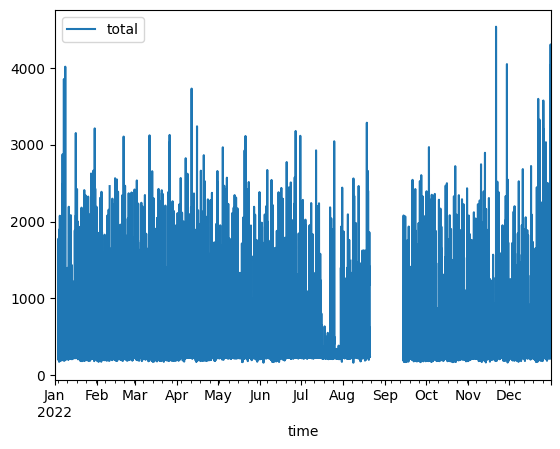

In [10]:
imputed_data = pd.DataFrame(
    index=pd.date_range(
        start=pd.Timestamp(target_year, 1, 1), 
        end=pd.Timestamp(target_year, 12, 31, 23, 59, 59),
        freq=freq,
        name="time",
        tz="utc"
    ),
)

imputed_data = pd.concat([imputed_data, resampled_data.loc[imputed_data.index]], axis=1)
display(imputed_data)
imputed_data.plot()

### Replace entire days according to the substitution mapping

<Axes: xlabel='time'>

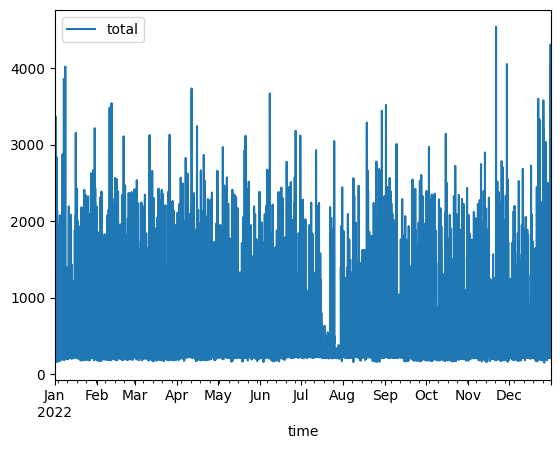

In [11]:
def dayspan_after(ts):
    return slice(ts, ts + pd.Timedelta(24*60*60-1, "s"))

for gap_date, substitution in target_substitution_mapping.iterrows():
    imputed_data.loc[dayspan_after(gap_date)] = resampled_data.loc[dayspan_after(substitution["replacement"])].values

imputed_data.plot()

## Write to file, unless NaNs are remaining

In [12]:
if imputed_data.isna().any(axis=None):
    raise AssertionError("Imputation Failed")
else:
    imputed_data.to_csv(f"../data/resampled-{freq}/imputed_total-{target_year}.csv")